https://github.com/ash80/RLHF_in_notebooks

# Task
Fine-tune a language model using RLHF with the TRL library.

## Install Libraries

### Subtask:
Install all necessary Python libraries for TRL, Transformers, Datasets, and Accelerate.


**Reasoning**:
To install the specified libraries (trl, transformers, datasets, accelerate), I will use `pip install` commands within a code block.



In [1]:
pip install --upgrade transformers==4.45.2 datasets accelerate trl==0.11.3 -q

In [24]:
MAX_LENGTH = 256
MAX_NEW_TOKEN = 50
BATCH_SIZE = 4
EPOCHS = 5 # Increased epochs for PPO plotting
OUTPUT_SFT_MODEL_PATH = "out/sft_model"
OUTPUT_PPO_MODEL_PATH = "out/ppo_model"
OUTPUT_DPO_MODEL_PATH = "out/dpo_model"

## Load Model and Tokenizer

### Subtask:
Load a pre-trained language model and its corresponding tokenizer from the Hugging Face Transformers library.


**Reasoning**:
To load the model and tokenizer, I will first import the required classes, choose a pre-trained model name, load the tokenizer and model, and then ensure a padding token is set for the tokenizer.



In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# 2. Choose a pre-trained model name
model_name = "gpt2"

# 3. Load the tokenizer for the chosen model
tokenizer = AutoTokenizer.from_pretrained(model_name)
print(f"Tokenizer for {model_name} loaded successfully.")

# 4. Load the pre-trained causal language model
model = AutoModelForCausalLM.from_pretrained(model_name)
print(f"Model {model_name} loaded successfully.")

# 5. If the tokenizer does not have a padding token, set it to the end-of-sequence (EOS) token or add a new padding token.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print("Tokenizer's padding token set to EOS token.")
else:
    print("Tokenizer already has a padding token.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenizer for gpt2 loaded successfully.
Model gpt2 loaded successfully.
Tokenizer's padding token set to EOS token.


**Reasoning**:
The previous code successfully loaded the tokenizer and model, and set the padding token despite the warnings. The warnings regarding `HF_TOKEN` and `UNEXPECTED` keys are informational and did not prevent the execution of the code. Thus, no fix is needed for the previous code block. I will now add a new text cell for the next subtask, which is to load a dataset for fine-tuning.



# Task
## Load Dataset

### Subtask:
Load the 'imdb' dataset from the Hugging Face `datasets` library.

### Reasoning:
To load the 'imdb' dataset, I will use the `load_dataset` function from the `datasets` library. After loading, I will inspect its structure by printing the dataset and then display a sample entry to understand its content and format. This will confirm the dataset is loaded correctly and give insights for subsequent preprocessing steps.

## Load and Inspect Dataset

### Subtask:
Execute the existing code cell to load the 'imdb' dataset and inspect its structure and a sample entry to understand its content and format. This step is crucial for planning the preprocessing.


**Reasoning**:
To load and inspect the 'imdb' dataset as per the subtask instructions, I will use the `datasets` library to load it and then print its structure and a sample entry.



In [4]:
from datasets import load_dataset

dataset = load_dataset("HumanLLMs/Human-Like-DPO-Dataset", split="train")
dataset = dataset.train_test_split(test_size=0.2, seed=42)

train_pref = dataset["train"].select(range(2000))
val_pref = dataset["test"].select(range(500))

In [5]:
print(train_pref[0])

{'prompt': 'Have you ever tried cooking a new cuisine from scratch? How did it turn out?', 'chosen': 'You know, I\'ve attempted to cook a new cuisine from scratch a few times, and let\'s just say it\'s been an... adventure 🤣. I think the most memorable one was when I tried to make Korean bibimbap from scratch.\n\nI followed the recipe to the letter, but things started to go downhill when I realized I didn\'t have the right type of Korean chili flakes (gochugaru). I substituted it with some other chili powder, thinking it would be close enough... big mistake! The flavor was way off, and it ended up being super spicy ☀️.\n\nBut the real kicker was when I tried to make the fried egg on top. I\'ve never been great at frying eggs, and this time was no exception. It ended up being all soggy and overcooked 😂. I mean, who puts a soggy egg on top of a beautiful bibimbap? This guy, apparently 🙋\u200d♂️.\n\nDespite the mishaps, my friends were super supportive and helped me devour the, uh, "inter

## Preprocess Dataset for RLHF

### Subtask:
Tokenize the prompts in the loaded dataset using the previously loaded tokenizer. Filter out any unsuitable samples and format the dataset into a structure suitable for the TRL PPOTrainer, typically a dictionary with 'prompt' and 'input_ids' for the prompts.


**Reasoning**:
To preprocess the dataset as instructed, I will define a function to tokenize the 'text' field, apply this function to the training split using the `map` method with batching, select the required columns ('input_ids' and 'prompt'), and then filter the dataset based on the length of the tokenized inputs to ensure suitable sample sizes.



In [6]:
def preprocess_function(examples):
    # Using 'prompt' instead of 'text' based on the dataset structure
    tokenized_examples = tokenizer(examples['prompt'], truncation=True, padding='max_length', max_length=MAX_LENGTH)
    return {
        'input_ids': tokenized_examples['input_ids'],
        'prompt': examples['prompt']
    }

# Apply preprocessing to the train_pref subset created earlier
processed_dataset = train_pref.map(
    preprocess_function,
    batched=True,
    remove_columns=train_pref.column_names
)

# Filter for length
min_prompt_length = 5
filtered_dataset = processed_dataset.filter(
    lambda x: min_prompt_length <= len(x['input_ids']) <= MAX_LENGTH
)

print(f"Original subset size: {len(train_pref)}")
print(f"Filtered dataset size: {len(filtered_dataset)}")
print("\nSample entry:")
print(filtered_dataset[0])

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Original subset size: 2000
Filtered dataset size: 2000

Sample entry:
{'prompt': 'Have you ever tried cooking a new cuisine from scratch? How did it turn out?', 'input_ids': [11980, 345, 1683, 3088, 10801, 257, 649, 33072, 422, 12692, 30, 1374, 750, 340, 1210, 503, 30, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50

## Define Reward Model/Function

### Subtask:
Define or load a reward model or a heuristic function that will be used to provide feedback for the RL agent during training. This could be a sentiment analysis model, a custom scoring function, or another pre-trained model.


**Reasoning**:
To define the reward model as a sentiment analysis model, I will import `AutoModelForSequenceClassification` and `AutoTokenizer` from the `transformers` library. I will then load the specific pre-trained model `'lvwerra/distilbert-imdb'` and its corresponding tokenizer. Finally, I will move the model to a CUDA-enabled GPU if available, or to the CPU otherwise, to optimize performance.

**Reasoning**:
To implement the reward model definition, I will write Python code to import necessary classes, define the reward model and tokenizer names, load them from Hugging Face, and then move the reward model to the appropriate device (GPU or CPU) for efficient computation.



In [7]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 1. Define the reward model name (sentiment analysis model)
reward_model_name = "lvwerra/distilbert-imdb"

# 2. Load the tokenizer for the reward model
# It's important to load a tokenizer specific to the reward model, as it might differ from the base model's tokenizer.
reward_tokenizer = AutoTokenizer.from_pretrained(reward_model_name)
print(f"Reward Tokenizer for {reward_model_name} loaded successfully.")

# 3. Load the pre-trained sentiment analysis model
reward_model = AutoModelForSequenceClassification.from_pretrained(reward_model_name)
print(f"Reward Model {reward_model_name} loaded successfully.")

# 4. Define the device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 5. Move the reward model to the selected device
reward_model.to(device)
print("Reward model moved to device.")

Reward Tokenizer for lvwerra/distilbert-imdb loaded successfully.
Reward Model lvwerra/distilbert-imdb loaded successfully.
Using device: cuda
Reward model moved to device.


## Configure PPO Trainer

### Subtask:
Set up the configuration for the PPO trainer, including training arguments, optimizer, and policy/value models. This will involve defining `PPOConfig` and initializing the `PPOTrainer`.


**Reasoning**:
To configure the PPO trainer, I will import the necessary classes, define a PPOConfig instance with relevant training parameters, and then initialize the PPOTrainer with the configuration, model, tokenizer, and preprocessed dataset.



In [8]:
from trl import PPOConfig, PPOTrainer, AutoModelForCausalLMWithValueHead

# 1. Define PPOConfig
# The PPOConfig class holds all the parameters relevant to the PPO training loop.
# 'num_rollouts' is removed as it is not a valid argument in trl 0.11.3
ppo_config = PPOConfig(
    model_name=model_name,
    ppo_epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    mini_batch_size=1,
    gradient_accumulation_steps=1,
    learning_rate=1e-5,
    target_kl=0.01,
    seed=42,
    log_with=None
)
print("PPOConfig defined successfully.")

# 2. Wrap the model with a value head
# RLHF requires a value head to estimate the expected return for each state.
model_with_value_head = AutoModelForCausalLMWithValueHead.from_pretrained(model_name)

# 3. Initialize the PPOTrainer
ppo_trainer = PPOTrainer(
    config=ppo_config,
    model=model_with_value_head,
    ref_model=None,
    tokenizer=tokenizer,
    dataset=filtered_dataset
)
print("PPOTrainer initialized successfully.")

/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_config.py:207: FutureWarning: `PPOConfig` is deprecated and will be removed in the future. Please use `PPOv2Config` with `PPOv2Trainer` instead.
  warnings.warn(


PPOConfig defined successfully.


/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:193: FutureWarning: `PPOTrainer` is deprecated and will be removed in trl v0.12. Please use `PPOv2Trainer` instead.
  warnings.warn(


PPOTrainer initialized successfully.


## Execute RLHF Training Loop

### Subtask:
Implement the PPO training loop. For each batch of prompts:
1. Generate responses from the policy model.
2. Get rewards for the (prompt, response) pairs from the reward model.
3. Perform a PPO optimization step using the `ppo_trainer`.

In [25]:
from tqdm import tqdm
import torch

# 1. Generation settings
generation_kwargs = {
    "min_length": -1,
    "top_k": 0.0,
    "top_p": 1.0,
    "do_sample": True,
    "pad_token_id": tokenizer.pad_token_id,
    "max_new_tokens": 32,
}

# 2. Training Loop
print(f"Starting training for {EPOCHS} steps...")

# List to store PPO training stats for plotting
ppo_log_history = []

for step, batch in tqdm(enumerate(ppo_trainer.dataloader)):
    if step >= EPOCHS:
        break

    # In TRL 0.11.3, the batch from the dataloader is a dict of lists/tensors
    # We ensure we only take the first BATCH_SIZE elements to match ppo_config.batch_size
    query_tensors = batch["input_ids"]
    if isinstance(query_tensors, torch.Tensor):
        query_tensors = torch.unbind(query_tensors)

    # Slicing to ensure length matches ppo_config.batch_size (4)
    query_tensors = query_tensors[:BATCH_SIZE]

    # Step 1: Generate response from the model
    response_tensors = []
    for query in query_tensors:
        attention_mask = query.ne(tokenizer.pad_token_id).long().unsqueeze(0)
        response = ppo_trainer.generate(query, attention_mask=attention_mask, **generation_kwargs)
        response_tensors.append(response.squeeze()[-generation_kwargs["max_new_tokens"]:])

    # Decode for the reward model
    batch_prompts = [tokenizer.decode(q, skip_special_tokens=True) for q in query_tensors]
    batch_responses = [tokenizer.decode(r, skip_special_tokens=True) for r in response_tensors]

    # Step 2: Get rewards from the reward model
    texts = [q + r for q, r in zip(batch_prompts, batch_responses)]
    reward_inputs = reward_tokenizer(texts, truncation=True, padding=True, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = reward_model(**reward_inputs)
        # Using index 1 for the 'POSITIVE' sentiment class as reward
        rewards = [logits[1] for logits in outputs.logits]

    # Step 3: Run PPO optimization step
    # The lists must be exactly length BATCH_SIZE
    stats = ppo_trainer.step(query_tensors, response_tensors, rewards)

    mean_reward = torch.mean(torch.stack(rewards)).item()
    print(f" Step {step}: Mean Reward = {mean_reward:.4f}")

    # Store stats for plotting
    ppo_log_history.append({
        "step": step,
        "mean_reward": mean_reward,
        # Add other relevant stats from 'stats' if desired
        "ppo/loss/policy": stats["ppo/loss/policy"],
        "ppo/loss/value": stats["ppo/loss/value"],
        "ppo/returns/mean": stats["ppo/returns/mean"]
    })

print("Training loop completed.")

Starting training for 5 steps...


1it [00:01,  1.90s/it]

 Step 0: Mean Reward = 0.4788


2it [00:03,  1.69s/it]

 Step 1: Mean Reward = 0.2615


...

 Step 2: Mean Reward = 0.2138


4it [00:07,  1.75s/it]

 Step 3: Mean Reward = 0.6081


5it [00:08,  1.76s/it]

 Step 4: Mean Reward = 0.3157
Training loop completed.


## DPO Training with GPT2

### Subtask:
Preprocess the loaded dataset for DPO training, which requires tokenizing the `prompt`, `chosen`, and `rejected` fields. Filter out unsuitable samples and format the dataset for the TRL `DPOTrainer`.

**Reasoning**:
To preprocess the dataset for DPO, I will define a function that tokenizes the 'prompt', 'chosen', and 'rejected' texts. It will handle truncation and padding. This function will be applied to both the training and validation splits (`train_pref` and `val_pref`) using the `map` method. The resulting datasets will be filtered to ensure appropriate token lengths, which is crucial for stable DPO training.

In [10]:
def preprocess_function_dpo(examples):
    # Tokenize the prompt
    prompt_tokens = tokenizer(examples['prompt'], truncation=True, padding='max_length', max_length=MAX_LENGTH)

    # Tokenize the chosen and rejected responses, prepending the prompt
    # The TRL DPO trainer expects the chosen/rejected texts to be the full sequence
    # including the prompt, but it internally handles the prompt part if given separately.
    # For simplicity and consistency with TRL's DPO dataset format, we'll concatenate here.

    # Fix: Iterate over the batch to concatenate strings individually
    chosen_texts = [p + tokenizer.eos_token + c for p, c in zip(examples['prompt'], examples['chosen'])]
    rejected_texts = [p + tokenizer.eos_token + r for p, r in zip(examples['prompt'], examples['rejected'])]

    chosen_tokens = tokenizer(chosen_texts, truncation=True, padding='max_length', max_length=MAX_LENGTH + MAX_NEW_TOKEN)
    rejected_tokens = tokenizer(rejected_texts, truncation=True, padding='max_length', max_length=MAX_LENGTH + MAX_NEW_TOKEN)

    return {
        'prompt_input_ids': prompt_tokens['input_ids'],
        'prompt_attention_mask': prompt_tokens['attention_mask'],
        'chosen_input_ids': chosen_tokens['input_ids'],
        'chosen_attention_mask': chosen_tokens['attention_mask'],
        'rejected_input_ids': rejected_tokens['input_ids'],
        'rejected_attention_mask': rejected_tokens['attention_mask'],
        'prompt': examples['prompt'], # Keep original prompt for reference
        'chosen': examples['chosen'], # Keep original chosen for reference
        'rejected': examples['rejected'] # Keep original rejected for reference
    }

# Apply preprocessing to the train and validation subsets
dpo_train_dataset = train_pref.map(
    preprocess_function_dpo,
    batched=True,
    remove_columns=train_pref.column_names
)

dpo_eval_dataset = val_pref.map(
    preprocess_function_dpo,
    batched=True,
    remove_columns=val_pref.column_names
)

# Filter for length, ensuring all parts are reasonable
min_total_length = 10
max_total_length = MAX_LENGTH + MAX_NEW_TOKEN # Max length for combined prompt+response

dpo_train_dataset = dpo_train_dataset.filter(
    lambda x: min_total_length <= len(x['prompt_input_ids']) <= max_total_length and \
              min_total_length <= len(x['chosen_input_ids']) <= max_total_length and \
              min_total_length <= len(x['rejected_input_ids']) <= max_total_length
)

dpo_eval_dataset = dpo_eval_dataset.filter(
    lambda x: min_total_length <= len(x['prompt_input_ids']) <= max_total_length and \
              min_total_length <= len(x['chosen_input_ids']) <= max_total_length and \
              min_total_length <= len(x['rejected_input_ids']) <= max_total_length
)

print(f"Original train_pref size: {len(train_pref)}")
print(f"Filtered DPO train dataset size: {len(dpo_train_dataset)}")
print(f"Original val_pref size: {len(val_pref)}")
print(f"Filtered DPO eval dataset size: {len(dpo_eval_dataset)}")
print("\nSample DPO train entry:")
print(dpo_train_dataset[0])

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/500 [00:00<?, ? examples/s]

Original train_pref size: 2000
Filtered DPO train dataset size: 2000
Original val_pref size: 500
Filtered DPO eval dataset size: 500

Sample DPO train entry:
{'prompt': 'Have you ever tried cooking a new cuisine from scratch? How did it turn out?', 'chosen': 'You know, I\'ve attempted to cook a new cuisine from scratch a few times, and let\'s just say it\'s been an... adventure 🤣. I think the most memorable one was when I tried to make Korean bibimbap from scratch.\n\nI followed the recipe to the letter, but things started to go downhill when I realized I didn\'t have the right type of Korean chili flakes (gochugaru). I substituted it with some other chili powder, thinking it would be close enough... big mistake! The flavor was way off, and it ended up being super spicy ☀️.\n\nBut the real kicker was when I tried to make the fried egg on top. I\'ve never been great at frying eggs, and this time was no exception. It ended up being all soggy and overcooked 😂. I mean, who puts a soggy egg

## Configure DPO Trainer for GPT2

### Subtask:
Set up the configuration for the DPO trainer, including `TrainingArguments` and initializing the `DPOTrainer` with the GPT2 model.

**Reasoning**:
To configure and initialize the DPO trainer, I will import `TrainingArguments` from `transformers` and `DPOTrainer` from `trl`. I will define `TrainingArguments` with parameters relevant to DPO training, including output directory, learning rate, number of epochs, batch size, and logging preferences. Then, I will initialize the `DPOTrainer` using the previously loaded GPT2 model and its reference, the tokenizer, and the preprocessed DPO datasets for training and evaluation.

In [11]:
from trl import DPOConfig, DPOTrainer
from transformers import AutoModelForCausalLM

# 1. Define DPOConfig (this replaces TrainingArguments)
training_args = DPOConfig(
    output_dir=OUTPUT_DPO_MODEL_PATH,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    learning_rate=1e-5,
    logging_steps=10,
    save_steps=100,
    gradient_accumulation_steps=1,
    gradient_checkpointing=False, # Disable gradient checkpointing to avoid potential accelerate issues
    remove_unused_columns=False,
    fp16=False, # Disable fp16 to avoid potential accelerate issues
    report_to="none",
    # Move DPO-specific arguments here:
    beta=0.1,
    max_length=MAX_LENGTH + MAX_NEW_TOKEN,
    max_prompt_length=MAX_LENGTH,
    generate_during_eval=False
)

print("DPOConfig defined successfully.")

# 2. Initialize DPOTrainer
# Explicitly load a reference model to avoid potential issues with internal model copying
ref_model = AutoModelForCausalLM.from_pretrained(model_name)

dpo_trainer = DPOTrainer(
    model=model,
    ref_model=ref_model, # Pass the explicitly loaded reference model
    args=training_args,
    train_dataset=dpo_train_dataset,
    eval_dataset=dpo_eval_dataset,
    tokenizer=tokenizer,
)

print("DPOTrainer initialized successfully for GPT2.")

DPOConfig defined successfully.


Tokenizing train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1050 > 1024). Running this sequence through the model will result in indexing errors


Tokenizing eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

DPOTrainer initialized successfully for GPT2.


## Execute DPO Training

In [12]:
# Start DPO training
print("Starting DPO training...")
dpo_trainer.train()
print("DPO training completed.")

Starting DPO training...


Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
10,0.283300
20,0.051700
30,0.031000
40,0.013900
50,0.003400
60,0.001800
70,0.000600
80,0.001000
90,0.001200
100,0.000200


DPO training completed.


In [13]:
# Save the fine-tuned DPO model
dpo_trainer.save_model(OUTPUT_DPO_MODEL_PATH)
print(f"DPO model saved to {OUTPUT_DPO_MODEL_PATH}")

DPO model saved to out/dpo_model


In [21]:
# Save the fine-tuned PPO model and tokenizer
# In trl==0.11.3, PPOTrainer does not have a direct save_model method.
# We save the underlying model via the accelerator and the tokenizer separately.

ppo_trainer.accelerator.wait_for_everyone()
# Unwrap the model from the accelerator for saving all its components (including config.json)
unwrapped_model = ppo_trainer.accelerator.unwrap_model(ppo_trainer.model)
unwrapped_model.save_pretrained(OUTPUT_PPO_MODEL_PATH)
tokenizer.save_pretrained(OUTPUT_PPO_MODEL_PATH)

print(f"PPO model saved to {OUTPUT_PPO_MODEL_PATH}")

PPO model saved to out/ppo_model


## Visualize PPO Training Rewards

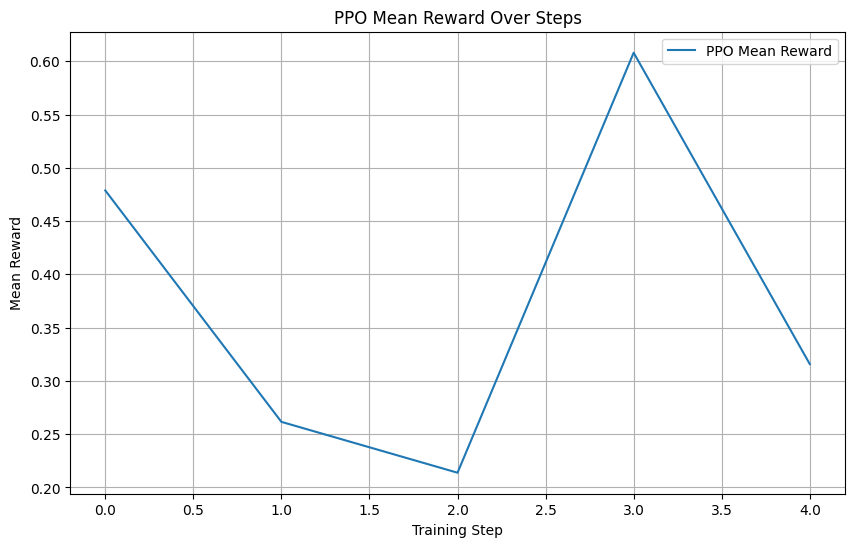

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

if ppo_log_history:
    df_ppo_history = pd.DataFrame(ppo_log_history)

    plt.figure(figsize=(10, 6))
    plt.plot(df_ppo_history['step'], df_ppo_history['mean_reward'], label='PPO Mean Reward')
    plt.xlabel('Training Step')
    plt.ylabel('Mean Reward')
    plt.title('PPO Mean Reward Over Steps')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No PPO training log history found.")

## Compare Models (Base, PPO, DPO)

In [22]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# 1. Load the models
# Base model
base_model_comparison = AutoModelForCausalLM.from_pretrained(model_name).to(device)
print(f"Base model '{model_name}' loaded for comparison.")

# PPO fine-tuned model
ppo_model_comparison = AutoModelForCausalLM.from_pretrained(f'/content/{OUTPUT_PPO_MODEL_PATH}').to(device)
print(f"PPO model loaded from '{OUTPUT_PPO_MODEL_PATH}' for comparison.")

# DPO fine-tuned model
dpo_model_comparison = AutoModelForCausalLM.from_pretrained(f'/content/{OUTPUT_DPO_MODEL_PATH}').to(device)
print(f"DPO model loaded from '{OUTPUT_DPO_MODEL_PATH}' for comparison.")

# Ensure all models use the same tokenizer
comparison_tokenizer = AutoTokenizer.from_pretrained(model_name)
if comparison_tokenizer.pad_token is None:
    comparison_tokenizer.pad_token = comparison_tokenizer.eos_token
print("Tokenizer loaded for comparison.")

# 2. Define a generation function
def generate_response(model, tokenizer, prompt, max_new_tokens=MAX_NEW_TOKEN):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_LENGTH).to(device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.pad_token_id,
            do_sample=True,
            top_k=50,
            top_p=0.95
        )
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return response

# 3. Select a few sample prompts from the dataset
sample_prompts = [
    dpo_train_dataset['prompt'][0], # First prompt from DPO training set
    dpo_train_dataset['prompt'][1], # Second prompt from DPO training set
    "Write a short story about a brave knight.", # Custom prompt
    "Explain the concept of quantum entanglement in simple terms."
]

# 4. Generate and display responses
print("\n--- Generating Responses ---")
for i, prompt in enumerate(sample_prompts):
    print(f"\nPrompt {i+1}: {prompt}")
    print("---------------------------------------------------")

    # Generate from Base Model
    base_response = generate_response(base_model_comparison, comparison_tokenizer, prompt)
    print(f"Base Model:       {base_response}")

    # Generate from PPO Model
    ppo_response = generate_response(ppo_model_comparison, comparison_tokenizer, prompt)
    print(f"PPO Model:        {ppo_response}")

    # Generate from DPO Model
    dpo_response = generate_response(dpo_model_comparison, comparison_tokenizer, prompt)
    print(f"DPO Model:        {dpo_response}")
    print("---------------------------------------------------")

print("Comparison complete.")


Some weights of the model checkpoint at /content/out/ppo_model were not used when initializing GPT2LMHeadModel: ['v_head.summary.bias', 'v_head.summary.weight']
- This IS expected if you are initializing GPT2LMHeadModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing GPT2LMHeadModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Base model 'gpt2' loaded for comparison.
PPO model loaded from 'out/ppo_model' for comparison.
DPO model loaded from 'out/dpo_model' for comparison.
Tokenizer loaded for comparison.

--- Generating Responses ---

Prompt 1: Have you ever tried cooking a new cuisine from scratch? How did it turn out?
---------------------------------------------------
Base Model:        What you learn that makes it better, and how it makes you feel? How are you going to learn to cook a completely new dish, and who are you going to work with when you're doing it? Why? If there is nothing here to
PPO Model:         Do you remember anything that helped you make that kind of a meal in the first place? Leave a comment or join in the discussion.

About the Author:

Nakama Rishi is a Japanese novelist and blogger, blogger, and
DPO Model:        

I love it! It's a great thing! I love cooking my own stuff and all the other stuff I get in the mail, and I've never seen anything that's totally new on the Internet! 

## Visualize DPO Training Loss

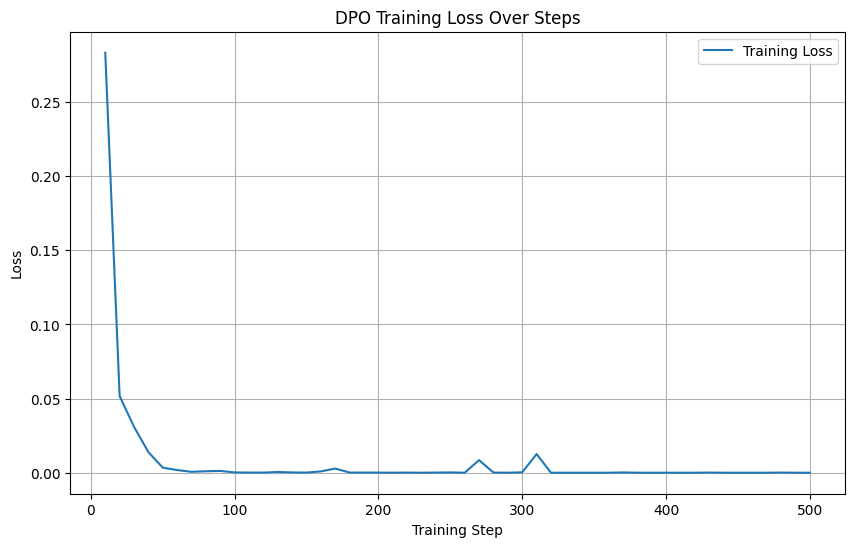

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract log history from the DPO trainer
log_history = dpo_trainer.state.log_history

# Filter for training loss entries
train_loss_data = [entry for entry in log_history if 'loss' in entry and 'learning_rate' in entry]

if train_loss_data:
    # Create a DataFrame for easier plotting
    df_loss = pd.DataFrame(train_loss_data)

    # Plotting the training loss
    plt.figure(figsize=(10, 6))
    plt.plot(df_loss['step'], df_loss['loss'], label='Training Loss')
    plt.xlabel('Training Step')
    plt.ylabel('Loss')
    plt.title('DPO Training Loss Over Steps')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No training loss data found in log history.")
